# Изучение рынка заведений общественного питания Москвы

Автор: Кропотов Валентин
Дата: 20.09.2025

## Цель и задачи

**Цель:** провести исследовательский анализ данных рынка общественного питания Москвы

**Задачи:**
1. Ознакомиться с содержимым предоставленных данных.
2. Провести предобработку данных.
3. Провести подробный анализ рынка общепита Москвы.
4. Сформулировать итоговый вывод и рекомендации.

## Данные

Датасеты с заведениями общественного питания Москвы, составленный на основе данных сервисов Яндекс Карты и Яндекс Бизнес на лето 2022 года. Информация, размещённая в сервисе Яндекс Бизнес, могла быть добавлена пользователями или найдена в общедоступных источниках. Она носит исключительно справочный характер. Всего два файла:

- Файл `rest_info.csv` содержит информацию о заведениях общественного питания.
- Файл `rest_price.csv` содержит информацию о среднем чеке в заведениях общественного питания.

### Описание датасета `rest_info`:

- `name` — название заведения;
- `address` — адрес заведения;
- `district` — административный район, в котором находится заведение, например Центральный административный округ;
- `category` — категория заведения, например «кафе», «пиццерия» или «кофейня»;
- `hours` — информация о днях и часах работы;
- `rating` — рейтинг заведения по оценкам пользователей в Яндекс Картах (высшая оценка — 5.0);
- `chain` — число, выраженное 0 или 1, которое показывает, является ли заведение сетевым (для маленьких сетей могут встречаться ошибки):
  - `0` — заведение не является сетевым;
  - `1` — заведение является сетевым.
- `seats` — количество посадочных мест.

### Описание датасета `rest_price`:

- `price` — категория цен в заведении, например «средние», «ниже среднего», «выше среднего» и так далее;
- `avg_bill` — строка, которая хранит среднюю стоимость заказа в виде диапазона, например:
  - «Средний счёт: 1000–1500 ₽»;
  - «Цена чашки капучино: 130–220 ₽»;
  - «Цена бокала пива: 400–600 ₽».
       и так далее;
- `middle_avg_bill` — число с оценкой среднего чека, которое указано только для значений из столбца avg_bill, начинающихся с подстроки «Средний счёт»:
  - Если в строке указан ценовой диапазон из двух значений, в столбец войдёт медиана этих двух значений.
  - Если в строке указано одно число — цена без диапазона, то в столбец войдёт это число.
  - Если значения нет или оно не начинается с подстроки «Средний счёт», то в столбец ничего не войдёт.
- `middle_coffee_cup` — число с оценкой одной чашки капучино, которое указано только для значений из столбца avg_bill, начинающихся с подстроки «Цена одной чашки капучино»:
  - Если в строке указан ценовой диапазон из двух значений, в столбец войдёт медиана этих двух значений.
  - Если в строке указано одно число — цена без диапазона, то в столбец войдёт это число.
  - Если значения нет или оно не начинается с подстроки «Цена одной чашки капучино», то в столбец ничего не войдёт.

## Структура проекта

1. Загрузка данных и знакомство с ними.
2. Предобработка данных.
3. Исследовательский анализ данных.
4. Итоговый вывод и рекомендации.

## 1. Загрузка данных и знакомство с ними.

Загрузим библиотеки необходимые для работы с датасетами (pandas), визуализации данных (seaborn, mtplotlib) и построения матриц корреляции (phik). А так же загрузим датасеты `rest_info` и `rest_price`.

In [1]:
# Импортируем библиотеки
import pandas as pd
import numpy as np

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

# Загружаем библиотеку для расчёта коэффициента корреляции phi_k
from phik import phik_matrix

# Убираем вывод экспоненциальной нотации
np.set_printoptions(suppress=True)

In [2]:
# Сохраняем датасетаы в переменных
rest_info = pd.read_csv('https://code.s3.yandex.net/datasets/rest_info.csv')
rest_price = pd.read_csv('https://code.s3.yandex.net/datasets/rest_price.csv')

- Познакомимся с датафреймом `rest_info` с помощью методов `head()` и `info()`:

In [3]:
# Первые пять строк датафрейма:
rest_info.head()

,id,name,category,address,district,hours,rating,chain,seats
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0


In [4]:
# Информация по столбцам и строкам:
rest_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        8406 non-null   object 
 1   name      8406 non-null   object 
 2   category  8406 non-null   object 
 3   address   8406 non-null   object 
 4   district  8406 non-null   object 
 5   hours     7870 non-null   object 
 6   rating    8406 non-null   float64
 7   chain     8406 non-null   int64  
 8   seats     4795 non-null   float64
dtypes: float64(2), int64(1), object(6)
memory usage: 591.2+ KB


Посчитаем количество пропусков:

In [5]:
# Посмотрим количество пропусков в абсолютном и относительном значениях в каждом столбце.
print(f'Количество пропусков:\n{rest_info.isna().sum()}\n\nОтносительное количество пропусков в процентах:\n{round(rest_info.isna().mean()*100,2)}')

Количество пропусков:
id             0
name           0
category       0
address        0
district       0
hours        536
rating         0
chain          0
seats       3611
dtype: int64

Относительное количество пропусков в процентах:
id           0.00
name         0.00
category     0.00
address      0.00
district     0.00
hours        6.38
rating       0.00
chain        0.00
seats       42.96
dtype: float64


Датасет `rest_info.csv` содержит 9 столбцов и 8406 строк с информацией о заведениях общепита Москвы.

Первичный анализ показал, что:

- Названия столбцов имеют удобные названия для дальнейшец работы и адекватны находящимся в них данных.
- Столбец `seats` можно переделать в целочисленный с пропусками. Остальные типы данных в столбцах соответствует находящимся в них значениях. Можно оптимизировать размерность числовых столбцов.
- Явные пропуски содержатся в столбцах `hours` и `seats` (6.38% и 42.96% соответственно). Так как датасет был собран из данных различных сервисов, вряд ли там будут значения-индикаторы, означающие отсутсвие данных.

- Знакомимся с датафреймом `rest_price` с помощью методов `head` и `info`:

In [6]:
rest_price.head()

,id,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,045780ada3474c57a2112e505d74b633,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
1,1070b6b59144425896c65889347fcff6,средние,Средний счёт:от 1000 ₽,1000.0,NaN
2,03ac7cd772104f65b58b349dc59f03ee,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
3,a163aada139c4c7f87b0b1c0b466a50f,средние,Средний счёт:400–600 ₽,500.0,NaN
4,8a343546b24e4a499ad96eb7d0797a8a,средние,NaN,NaN,NaN


In [7]:
rest_price.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4058 entries, 0 to 4057
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4058 non-null   object 
 1   price              3315 non-null   object 
 2   avg_bill           3816 non-null   object 
 3   middle_avg_bill    3149 non-null   float64
 4   middle_coffee_cup  535 non-null    float64
dtypes: float64(2), object(3)
memory usage: 158.6+ KB


Посчитаем количество пропусков:

In [8]:
# Посмотрим количество пропусков в абсолютном и относительном значениях в каждом столбце.
print(f'Количество пропусков:\n{rest_price.isna().sum()}\n\nОтносительное количество пропусков в процентах:\n{round(rest_price.isna().mean()*100,2)}')

Количество пропусков:
id                      0
price                 743
avg_bill              242
middle_avg_bill       909
middle_coffee_cup    3523
dtype: int64

Относительное количество пропусков в процентах:
id                    0.00
price                18.31
avg_bill              5.96
middle_avg_bill      22.40
middle_coffee_cup    86.82
dtype: float64


Датасет `rest_price.csv` содержит 5 столбцов и 4058 строк, в которых находится информация о ценах в заведениях общепита Москвы.

После первичного анализа видно, что:

- Названия столбцов написаны в удобном для дальнейшей работы стиле и адекватны данным, которые в них хранятся.
- Типы данных на первый взгляд соответствуют содержанию, но нужно проверить уникальные значения в столбцах `middle_avg_bill` и `middle_coffee_cup`.
- Пропуски есть во всех столбцах, кроме `id`. Часть пропусков (или даже все) в столбцах `middle_avg_bill` и `middle_coffee_cup` вызвана спецификой их заполнения.

Поверхностное знакомство с данными показывает, что в них огромное количество пропусков видимо из-за специфики сбора информации из открытых источников.

Перед объединением нужно проверить все ли значения столбца `id` в обоих датасетах уникальны.

In [9]:
# Ищем дубликаты в rest_info в столбце id:
rest_info.duplicated(subset='id').sum()

0

In [10]:
#Ищем дубликаты в rest_price в столбце id:
rest_price.duplicated(subset='id').sum()

0

В данном случае для выполнения заданий основным датасетом является `rest_info`. К нему мы и будем присоединять датасет `rest_price` с параметром `how='left'`.

In [11]:
# Объединяем датасеты:
df = rest_info.merge(rest_price,
               how='left',
               on='id')

In [12]:
# Смотрим результат:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              7870 non-null   object 
 6   rating             8406 non-null   float64
 7   chain              8406 non-null   int64  
 8   seats              4795 non-null   float64
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
dtypes: float64(4), int64(1), object(8)
memory usage: 919.4+ KB


## 2. Предобработка данных

### 2.1 Оптимизируем типы данных числовых столбцов

Воспользуемся методом `to_numeric` с параметром `downcast`:

- В столбце `chain` хранятся значения только `0` и `1`. Сделаем его целочисленным с минимальной размерностью.
- В столбце `rating` хранятся вещественные числа от `0` до `5`. Соответственно нам подходит значения параметра `downcast='float'`. 

In [13]:
df['chain'] = pd.to_numeric(df['chain'], downcast='integer')
df['chain'].dtype

dtype('int8')

In [14]:
df['rating'] = pd.to_numeric(df['rating'], downcast='float')
df['rating'].dtype

dtype('float32')

- Изучим данные в столбце `seats`:

In [15]:
df['seats'].describe()

count    4795.000000
mean      108.421689
std       122.833396
min         0.000000
25%        40.000000
50%        75.000000
75%       140.000000
max      1288.000000
Name: seats, dtype: float64

In [16]:
df['seats'].unique()

array([  nan,    4.,   45.,  148.,   79.,   65.,  102.,  180.,   96.,
         25.,   46.,   40.,  247.,   21.,    8.,   35.,  240.,   85.,
         12.,   60.,  120.,   16.,   80.,   50.,   44.,   43.,   90.,
          0.,  198.,   95.,  350.,  124.,   10.,   70.,   48.,    6.,
         98.,   30.,   52.,   20.,    2.,   18.,   22.,   15.,   28.,
        300.,   75.,   32.,  100.,  110.,  230.,  250.,  130.,   84.,
        398.,   27.,  286.,  145.,   36.,   97.,  226.,  140.,  166.,
        202.,   94.,  189.,   53.,  104.,   72.,  131.,  105.,   55.,
         17.,    1.,  115.,  310.,   77.,  160.,  320.,   34.,  150.,
        200.,  107.,   26.,   24.,   49.,  220.,  125.,    7.,  500.,
        210.,  225.,  273.,  106.,  112.,  176.,   69.,  229.,   62.,
          9.,  239.,  246.,   42.,  188.,  174.,   14.,   76.,  232.,
         68.,  625.,   83.,   92.,  128.,  245.,   58.,   67.,   82.,
          3.,   63.,   38.,   56.,  190.,   47.,   61.,  307.,  138.,
        217.,   64.,

Минимум - `0`, максимум - `1288`. Все значения целочисленные (что логично), но есть пропуски. Значит нам подойдет тип `UInt16`

In [17]:
df['seats'] = df['seats'].astype('UInt16')
df['seats'].dtype

UInt16Dtype()

- Посмотрим данные в столбце `middle_coffee_cup`:

In [18]:
df['middle_coffee_cup'].describe()

count     535.000000
mean      174.721495
std        88.951103
min        60.000000
25%       124.500000
50%       169.000000
75%       225.000000
max      1568.000000
Name: middle_coffee_cup, dtype: float64

In [19]:
df['middle_coffee_cup'].unique()

array([  nan,  170.,  145.,  150.,  180.,  120.,  100.,  256.,  160.,
        250.,  165.,  149.,  135.,  220.,  175.,  195.,   60.,  214.,
         75.,   89.,   95.,  204.,   90.,  140.,  125.,  162.,  155.,
        154.,  297.,  205.,  124.,  200.,  190.,  134.,  139.,  287.,
        225.,  230.,  237.,  290.,  254.,  279.,  174.,  179.,  295.,
        245.,  105.,  285.,  270.,   84.,  127.,   80.,  112.,  185.,
        210.,  325.,  159.,  215.,  110.,  266.,  242.,  137.,  255.,
        240.,  217.,  315.,  130.,  167.,  169.,  235., 1568.,   79.,
        260.,  300.,  291.,  275.,  115.,  328.,   94.,  265.,  184.,
        229.,  164.,  172.,  259.,  246.,  199.,  138.,  375.,  189.,
        320.,  197.,  227.,  102.,  119.,  144.,  129.])

Все значения положительные и целочисленные с максимумом в `1568`. `UInt16` тоже подойдет.

In [20]:
df['middle_coffee_cup'] = df['middle_coffee_cup'].astype('UInt16')
df['middle_coffee_cup'].dtype

UInt16Dtype()

- Теперь `middle_avg_bill`:

In [21]:
df['middle_avg_bill'].describe()

count     3149.000000
mean       958.053668
std       1009.732845
min          0.000000
25%        375.000000
50%        750.000000
75%       1250.000000
max      35000.000000
Name: middle_avg_bill, dtype: float64

In [22]:
df['middle_avg_bill'].unique()

array([   nan,  1550.,  1000.,   500.,   199.,   250.,  1100.,   330.,
        1500.,   400.,   245.,   425.,   900.,   240.,   225.,   328.,
         300.,   345.,   230.,   650.,   750.,  1250.,  1750.,  2250.,
         600.,   450.,   850.,  2100.,   349.,   200.,   120.,   269.,
        1300.,  1150.,   355.,   275.,  1200.,   575.,   350.,   700.,
         284.,   150.,   362.,   325.,  2000.,   291.,   280.,  2750.,
        1400.,  2500.,  2150.,  5000.,   825.,   625.,  3250.,   675.,
         475.,  1690.,   925.,  1050.,   340.,   950.,  1025.,   321.,
         550.,   360.,   375.,   317.,   324.,   343.,   140.,   165.,
         215.,   549.,   175.,   313.,  1375.,   100.,   975., 11000.,
         800.,   295.,  3750.,  1350.,   430.,   130.,   525.,   344.,
         185.,  1800.,   875.,   480.,   695.,   261.,  1450.,  3000.,
         180.,   404.,   235.,   366.,   304.,  4500.,   560.,   470.,
         387.,  1850.,  1900.,   315.,   363.,   260.,  2900.,   210.,
      

Значения положительные и целочисленные. Тоже `UInt16`.

Значение `0` для этого столбца аномально - медиана среднего чека не может быть равна нулю. Это либо техническая ошибка, либо индикатор пропуска. Нужно посмотреть.

In [23]:
df[df['middle_avg_bill']==0]

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
3688,502d91289bc5470eabd77fd77cc79821,Кофемания,кофейня,"Москва, улица Новый Арбат, 19",Центральный административный округ,"ежедневно, круглосуточно",4.5,1,200,высокие,Средний счёт:от 0 ₽,0.0,<NA>


Либо аномалия, либо недобросовестность того, кто заполнял эту информацию. Хотя может это показатель того, что в заведение можно просто зайти и посидеть, ничего не заказывая. Не знаю, что такое "Кофемания", но обычно так нельзя делать) В общем ничего критичного, можно заменить на пропуск.

In [24]:
df.loc[df['middle_avg_bill'] == 0, 'middle_avg_bill'] = pd.NA
df['middle_avg_bill'] = df['middle_avg_bill'].astype('UInt16')
df['middle_avg_bill'].dtype

UInt16Dtype()

По-хорошему тут бы еще заменить тип для `category`, `district` и `price` с `object` на `category`, но потом могут возникнуть проблемы с переименованием значений в этих столбцах, если это понадобится.

- Проверим результат:

In [25]:
df.dtypes

id                    object
name                  object
category              object
address               object
district              object
hours                 object
rating               float32
chain                   int8
seats                 UInt16
price                 object
avg_bill              object
middle_avg_bill       UInt16
middle_coffee_cup     UInt16
dtype: object

### 2.2 Работаем с пропусками

Для начала посчитаем их абсолютное и относительное количество:

In [26]:
print(f'Количество пропусков:\n{df.isna().sum()}\n\nОтносительное количество пропусков в процентах:\n{round(df.isna().mean()*100,2)}')

Количество пропусков:
id                      0
name                    0
category                0
address                 0
district                0
hours                 536
rating                  0
chain                   0
seats                3611
price                5091
avg_bill             4590
middle_avg_bill      5258
middle_coffee_cup    7871
dtype: int64

Относительное количество пропусков в процентах:
id                    0.00
name                  0.00
category              0.00
address               0.00
district              0.00
hours                 6.38
rating                0.00
chain                 0.00
seats                42.96
price                60.56
avg_bill             54.60
middle_avg_bill      62.55
middle_coffee_cup    93.64
dtype: float64


По пропускам можно сказать следующее:

- При объединении датасетов пропусков стало сильно больше из-за того, что в основном датасете `rest_info` было примерно в два раза больше строк, чем в датасете `rest_price`. При "левом" объединении, соответственно, для всех `id`, которых не было в в датасете с ценами, недостающая информация пополнила список пропусков.
- Пропуски в столбцах `middle_avg_bill` и `middle_coffee_cup` зависят от информации (или пропусков) в столбце `avg_bill`.
- У меня нет никаких особенных гипотез возникновения пропусков, кроме специфики сбора информации. Т.е. пропуски означают либо технические ошибки, либо просто отсутствие информации в первоисточнике. Как я понимаю, данные в сервисах "Яндекс Карты" и "Яндекс Бизнес" (кроме оценок) заполняют сами владельцы. В таком случае получается, что чем менее, так скажем, "серьезное" заведение, тем меньше вероятность, что владелец будет серьезно относится к данным по среднему чеку и расписанию в этих сервисах. Вряд ли люди заранее будет искать такую информацию для булочных или точек быстрого питания, тем более если оттуда нельзя заказать доставку. Для проверки гипотезы можно посмотреть абсолютное и относительное количество пропусков `avg_bill`, `seats` и `hours` с группировкой по столбцам `district` и `category`.

In [27]:
# Создадим функции для вычисления суммарного кол-ва пропусков и доли пропусков в процентах:
def sum_nans(x):
    return x.isna().sum()
def mean_nans(x):
    return x.isna().mean()*100

- Считаем функции для пропусков в столбце `avg_bill`

In [28]:
df.groupby('district')['avg_bill'].agg([sum_nans, mean_nans]).sort_values(by='mean_nans', ascending=False)

,sum_nans,mean_nans
district,,
Юго-Восточный административный округ,478,66.946779
Восточный административный округ,488,61.152882
Юго-Западный административный округ,433,61.071932
Северо-Восточный административный округ,523,58.698092
Южный административный округ,518,58.071749
Западный административный округ,489,57.461810
Северо-Западный административный округ,224,54.767726
Северный административный округ,487,54.111111
Центральный административный округ,950,42.372881


Вообще не разбираюсь в административных округах Москвы, но тут явно видно, что в ЦАО меньше всего пропусков. Я так полагаю, что в центре большое сосредоточение точек общепита покрупнее.

In [29]:
df.groupby('category')['avg_bill'].agg([sum_nans, mean_nans]).sort_values(by='mean_nans', ascending=False)

,sum_nans,mean_nans
category,,
булочная,203,79.296875
кафе,1680,70.647603
быстрое питание,365,60.530680
ресторан,1003,49.094469
кофейня,692,48.973815
столовая,134,42.539683
пиццерия,233,36.808847
"бар,паб",280,36.601307


Вроде как гипотеза подтверждается - больше всего пропусков в категориях, для которых информация в сети про средний чек не особо критична. Либо предприниматели в этих категориях так считают (а может они просто безответственные).

- Считаем функции для пропусков в столбце `seats`

In [30]:
df['seats'].describe()

count    4795.000000
mean      108.421689
std       122.833396
min         0.000000
25%        40.000000
50%        75.000000
75%       140.000000
max      1288.000000
Name: seats, dtype: float64

Минимальное значени посадочных мест 0 может означать, что заведение работает только на доставку, временно закрыто или отсутствие данных. Это не обязательно индикатор пропуска.

In [31]:
df.groupby('district')['seats'].agg([sum_nans, mean_nans]).sort_values(by='mean_nans', ascending=False)

,sum_nans,mean_nans
district,,
Юго-Восточный административный округ,364,50.980392
Восточный административный округ,380,47.619048
Центральный административный округ,1064,47.457627
Западный административный округ,373,43.830787
Северо-Восточный административный округ,386,43.322110
Юго-Западный административный округ,261,36.812412
Южный административный округ,325,36.434978
Северный административный округ,315,35.000000
Северо-Западный административный округ,143,34.963325


Здесь ситуация уже не такая однозначная, но ЮВАО и ВАО все еще в топе по процентам пропусков.

In [32]:
df.groupby('category')['seats'].agg([sum_nans, mean_nans]).sort_values(by='mean_nans', ascending=False)

,sum_nans,mean_nans
category,,
кафе,1160,48.780488
столовая,151,47.936508
кофейня,662,46.850672
булочная,108,42.187500
быстрое питание,254,42.122720
"бар,паб",297,38.823529
ресторан,773,37.836515
пиццерия,206,32.543444


Здесь тоже ситауция не однозначная - проценты пропусков распределены относительно равномерно, но в барах и пиццериях опять меньше всего пропусков. Возможно еще, что количество мест в заведении может меняться со временем или по сезонам, поэтому владельцы не заполняют эту информацию.

- Считаем функции для пропусков в столбце `hours`

In [33]:
df.groupby('district')['hours'].agg([sum_nans, mean_nans]).sort_values(by='mean_nans', ascending=False)

,sum_nans,mean_nans
district,,
Юго-Восточный административный округ,85,11.904762
Северо-Западный административный округ,40,9.779951
Восточный административный округ,75,9.398496
Юго-Западный административный округ,59,8.321580
Западный административный округ,66,7.755582
Южный административный округ,65,7.286996
Северо-Восточный административный округ,61,6.846240
Северный административный округ,54,6.000000
Центральный административный округ,31,1.382694


Опять ЮВАО в топе, а в ЦАО меньше всего пропусков.

In [34]:
df.groupby('category')['hours'].agg([sum_nans, mean_nans]).sort_values(by='mean_nans', ascending=False)

,sum_nans,mean_nans
category,,
кафе,375,15.769554
быстрое питание,33,5.472637
ресторан,74,3.622124
столовая,9,2.857143
булочная,7,2.734375
"бар,паб",18,2.352941
кофейня,15,1.061571
пиццерия,5,0.789889


В пиццериях и барах во всех трех случаях было очень мало пропусков. А категория "кафе" в лидерах по проценту пропусков во всех трех случаях. Мне сложно предположить почему так (кроме вышеупомянутой "серьезности" заведения), но результат налицо.

### 2.3 Проверяем данные на дубликаты
Сначала нужно привести все значения всех столбцов с типом `object` к единому стилю:

In [35]:
# Перебираем в цикле все значения столбцов с типом данных "object"
for col in df.select_dtypes(include='object'):
    df[col] = df[col].str.lower()
    df[col] = df[col].str.strip()

- Проверяем неявные дубликаты:

In [36]:
# Названия заведений я уже приводил к нижнему регистру
df.duplicated(subset=['name', 'address']).sum()

4

Обнаружено 4 неявных дубликата

In [37]:
df = df.drop_duplicates(subset=['name', 'address'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8402 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8402 non-null   object 
 1   name               8402 non-null   object 
 2   category           8402 non-null   object 
 3   address            8402 non-null   object 
 4   district           8402 non-null   object 
 5   hours              7867 non-null   object 
 6   rating             8402 non-null   float32
 7   chain              8402 non-null   int8   
 8   seats              4792 non-null   UInt16 
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3148 non-null   UInt16 
 12  middle_coffee_cup  535 non-null    UInt16 
dtypes: UInt16(3), float32(1), int8(1), object(8)
memory usage: 705.6+ KB


### 2.4 Для дальнейшей работы добавим новый столбец
Столбец is_24_7 с булевым типом данных с обозначением того, что заведение работает ежедневно и круглосуточно, то есть 24/7.

In [38]:
df['is_24_7'] = df['hours']=='ежедневно, круглосуточно'
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8402 entries, 0 to 8405
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8402 non-null   object 
 1   name               8402 non-null   object 
 2   category           8402 non-null   object 
 3   address            8402 non-null   object 
 4   district           8402 non-null   object 
 5   hours              7867 non-null   object 
 6   rating             8402 non-null   float32
 7   chain              8402 non-null   int8   
 8   seats              4792 non-null   UInt16 
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3148 non-null   UInt16 
 12  middle_coffee_cup  535 non-null    UInt16 
 13  is_24_7            8402 non-null   bool   
dtypes: UInt16(3), bool(1), float32(1), int8(1), object(8)
memory usage: 713.8+ KB


**Общие выводы:**
- Для столбцов с числовыми типами данных была проделана оптимизация рамерности ячеек.
- Учитывая дальнейшие задания я предпочел оставить пропуски как есть, либо заменить на индикатор. В блоке с исследовательстким анализом данных довольно редко будут задействоваться столбцы, в которых есть пропуски, и я не знаю, как лучше заполнить эти пропуски (если это вообще возможно). Думаю, что лучше оставить пропуски как есть, так проще будет фильтровать данные в дальнейшем.
- В данных не обнаружено дубликатов.
- Добавлен новый столбец `is_24_7`, который хранит булевый тип данных о том, работает ли заведение 24/7. `True` - если работает круглосуточно, семь дней в неделю, `False` - если нет.

## 3. Исследовательский анализ данных

### 3.1 Количество заведений общепита по каждой категории
Посмотрим какое количество заведений есть в каждой категории

In [39]:
# Считаем количество заведений для каждой категории
df['category'].value_counts()

кафе               2376
ресторан           2042
кофейня            1413
бар,паб             764
пиццерия            633
быстрое питание     603
столовая            315
булочная            256
Name: category, dtype: int64

В данных представлены `8` категорий заведений общепита:
1. Кафе
2. Ресторан
3. Кофейня
4. Бар, паб
5. Пиццерия
6. Быстрое питание
7. Столовая
8. Булочная

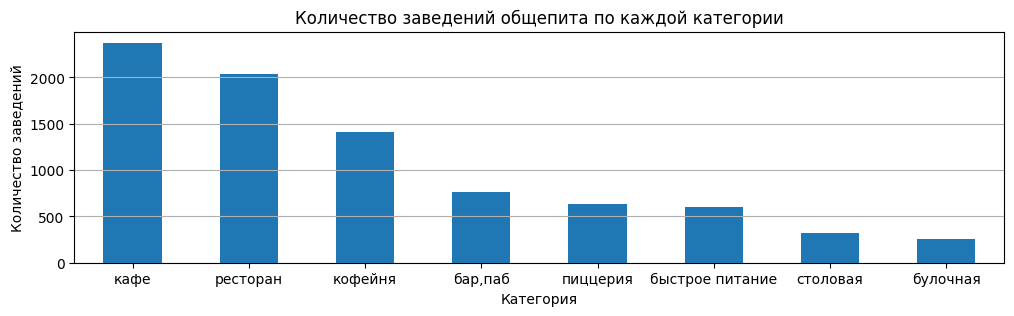

In [40]:
# Задаем размер визуализации
plt.figure(figsize=(12, 3))
# Строим столбчатую диаграмму
df['category'].value_counts().plot(kind='bar',
                                  title='Количество заведений общепита по каждой категории',
                                  legend=False,
                                  ylabel='Количество заведений',
                                  xlabel='Категория',
                                  rot=0
                                  )
# Добавляем сетку для оси Y
plt.grid(axis='y')

На графике видно, что `Кафе`, `Ресторан`(>2000 заведений) и `Кофейня`(почти 1500 заведений) с сильным отрывом являются самыми большими категориями общепита с точки зрения количества заведений. `Столовая` и `Булочная`(<500), в свою очередь, самые отстающие по этому показателю. `Бар`, `Пиццерия` и `Быстрое питание`(от 500 до 1000) в середине.

### 3.2 Административные районы и категории в ЦАО
Посчитаем количество упоминаний в датасете каждого значения в столбце `district`

In [41]:
# Считаем количество значений
df['district'].value_counts()

центральный административный округ         2242
северный административный округ             898
южный административный округ                892
северо-восточный административный округ     890
западный административный округ             850
восточный административный округ            798
юго-восточный административный округ        714
юго-западный административный округ         709
северо-западный административный округ      409
Name: district, dtype: int64

В данных представленны 9 административных округов Москвы:
1. Центральный административный округ
2. Северный административный округ
3. Южный административный округ
4. Северо-восточный административный округ
5. Западный административный округ
6. Восточный административный округ
7. Юго-восточный административный округ
8. Юго-западный административный округ
9. Северо-западный административный округ

Для лучшей читаемости на графике нужно изменить значения в столбце `district`.

In [42]:
# Создадим словарь для замены значений 
replace_dict = {
    'центральный административный округ': 'ЦАО',
    'северный административный округ': 'САО',
    'южный административный округ': 'ЮАО',
    'северо-восточный административный округ': 'СВАО',
    'западный административный округ': 'ЗАО',
    'восточный административный округ': 'ВАО',
    'юго-восточный административный округ': 'ЮВАО',
    'юго-западный административный округ': 'ЮЗАО',
    'северо-западный административный округ': 'СЗАО'
}
# Заменим значения в столбце "district"
df['district'] = df['district'].replace(replace_dict)

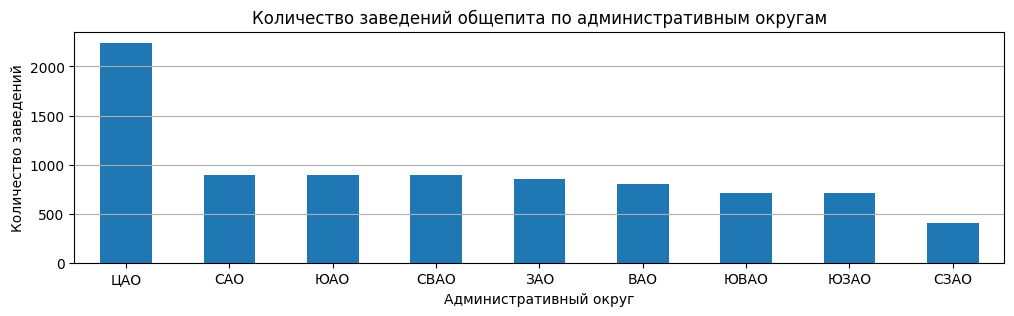

In [43]:
# Задаем размер визуализации
plt.figure(figsize=(12, 3))

# Строим столбчатую диаграмму
df['district'].value_counts().plot(kind='bar',
                                  title='Количество заведений общепита по административным округам',
                                  legend=False,
                                  ylabel='Количество заведений',
                                  xlabel='Административный округ',
                                  rot=0
                                  )
# Включаем сетку для оси Y
plt.grid(axis='y')

На графике явно видно доминирование `ЦАО` по количеству заведений, причем с большим отрывом. `СЗАО` тоже выделяется на фоне остальных округов, но в другую сторону - там меньше всего заведений. Остальные семь округов идут примерно вровень.

- Посчитем распределение категорий заведений в ЦАО

In [44]:
# Считаем требуемую метрику
df.loc[df['district']=='ЦАО','category'].value_counts(normalize=True)

ресторан           0.298840
кафе               0.206958
кофейня            0.190901
бар,паб            0.162355
пиццерия           0.050401
быстрое питание    0.038805
столовая           0.029438
булочная           0.022302
Name: category, dtype: float64

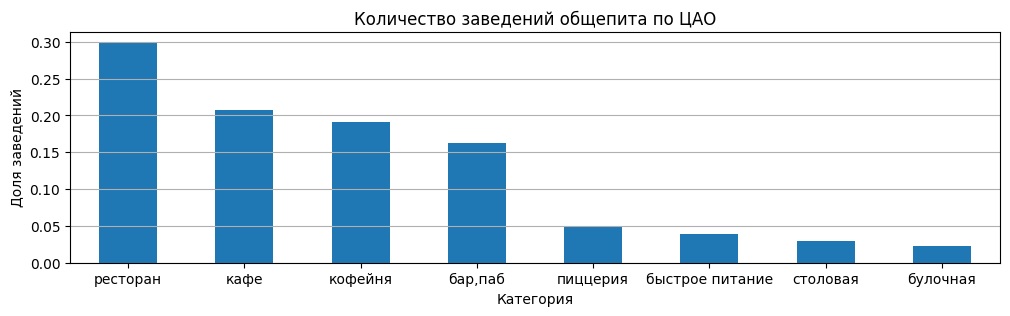

In [45]:
# Сохраним в отдельной переменной, чтобы не удлиннять код для визуализации
df_central = df.loc[df['district']=='ЦАО','category'].value_counts(normalize=True)

# Строим столбчатую диаграмму
plt.figure(figsize=(12, 3))
df_central.plot(kind='bar',
                title='Количество заведений общепита по ЦАО',
                legend=False,
                ylabel='Доля заведений',
                xlabel='Категория',
                rot=0
                )
plt.grid(axis='y')

В `ЦАО` набюдается нетипичная ситуация, в сравнении со средним по Москве, по распределению категорий заведений общепита. Сильно меньшая доля кафе и сильно возросшая доля ресторанов. Скорее всего рестораны считаются более престижными заведениями, чем кафе, поэтому не удивительно, что в центре города их доля возрастает.

### 3.3 Сетевые и не сетевые заведения.
Для начала посмотрим на соотношение сетевых и не сетевых заведений

In [46]:
# Смотрим соотношение с параметром normalize=True
df['chain'].value_counts(normalize=True)

0    0.618781
1    0.381219
Name: chain, dtype: float64

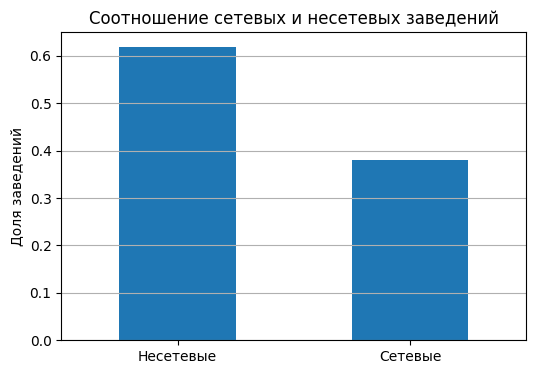

In [47]:
# Строим столбчатую диаграмму
plt.figure(figsize=(6, 4))
df['chain'].value_counts(normalize=True).plot(kind='bar',
                                          title='Соотношение сетевых и несетевых заведений',
                                          legend=False,
                                          ylabel='Доля заведений',
                                          rot=0
                                          )
# Заменяем подписи на графике для лучшей читаемости
plt.xticks(ticks=[0, 1], labels=['Несетевые', 'Сетевые'])
plt.grid(axis='y')

Несетевых заведений примерно в полтора раза больше, чем сетевых.

- Рассмотрим сетевые и несетевые заведения в разрезе категорий

In [48]:
# Создадим датафрейм с группировкой по категориям и посчитаем долю сетевых и несетевых заведений
group_category = df.groupby('category')['chain'].value_counts(normalize=True).unstack().sort_values(by=0, ascending=False)
display(group_category)

chain,0,1
category,,
"бар,паб",0.780105,0.219895
столовая,0.720635,0.279365
кафе,0.672138,0.327862
ресторан,0.642997,0.357003
быстрое питание,0.615257,0.384743
кофейня,0.490446,0.509554
пиццерия,0.478673,0.521327
булочная,0.386719,0.613281


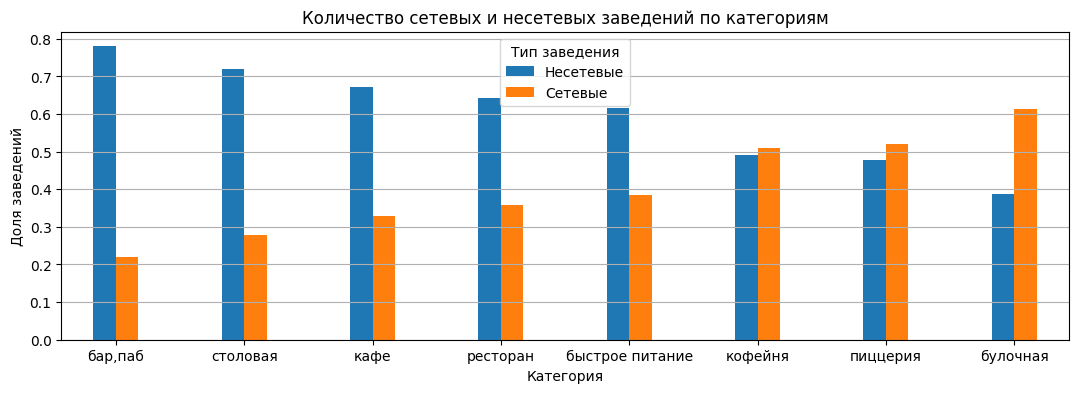

In [49]:
# Для читаемости заменим метки столбцов
group_category.columns = ['Несетевые', 'Сетевые']

# Построим группированную столбчатую диаграмму
group_category.plot(kind='bar', figsize=(13, 4), width=0.35)

# Настроим визуализацию
plt.title('Количество сетевых и несетевых заведений по категориям')
plt.xlabel('Категория')
plt.ylabel('Доля заведений')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.legend(title='Тип заведения', loc='upper center')

Выводы из визуализации:
- `Булочные` сильно чаще остальных бывают сетевыми
- `Кофейни` и `пиццерии` чаще бывают сетевыми, чем несетевыми, но разница небольшая
- Остальные категории в подавляющем большинстве случаев несетевые

### 3.4 Посадочные места
Начнем с рассмотрения основных статистик для столбца `seats`

In [50]:
# Смотрим основные статистики
df['seats'].describe()

count    4792.000000
mean      108.361436
std       122.841130
min         0.000000
25%        40.000000
50%        75.000000
75%       140.000000
max      1288.000000
Name: seats, dtype: float64

In [51]:
# Узнаем моду
df['seats'].mode()

0    40
dtype: Int64

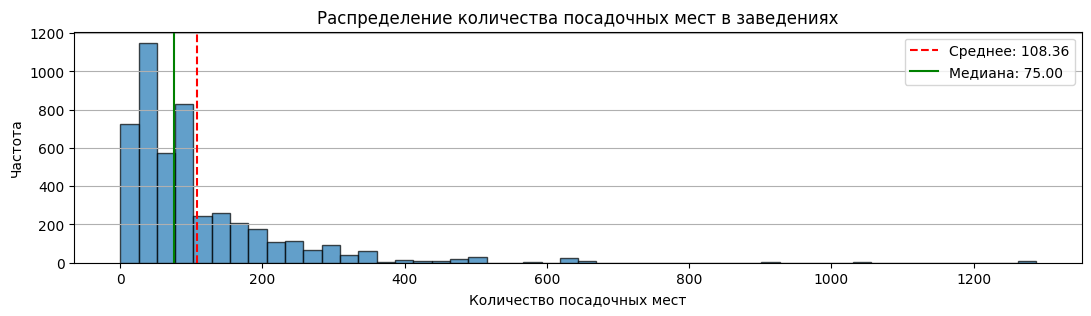

In [52]:
# Создаем датафрейм без пропусков в столбце seats
df_clean = df.dropna(subset=['seats'])

# Построим гистограмму
plt.figure(figsize=(13, 3))
plt.hist(df_clean['seats'], bins=50, alpha = 0.7, edgecolor='black')
# Линии среднего и медианы
plt.axvline(df_clean['seats'].mean(), color='red', linestyle='--', label=f"Среднее: {df_clean['seats'].mean():.2f}")
plt.axvline(df_clean['seats'].median(), color='green', linestyle='-', label=f"Медиана: {df_clean['seats'].median():.2f}")
plt.legend()
plt.title('Распределение количества посадочных мест в заведениях')
plt.xlabel('Количество посадочных мест')
plt.ylabel('Частота')
plt.grid(axis='y')

Распределение с очень большим правым хвостом. Среднее, соответственно, тоже сдвинуто вправо относительно медианы. Мода, т.е. самое частовстречающееся значение, находится на уровне первого квартиля.

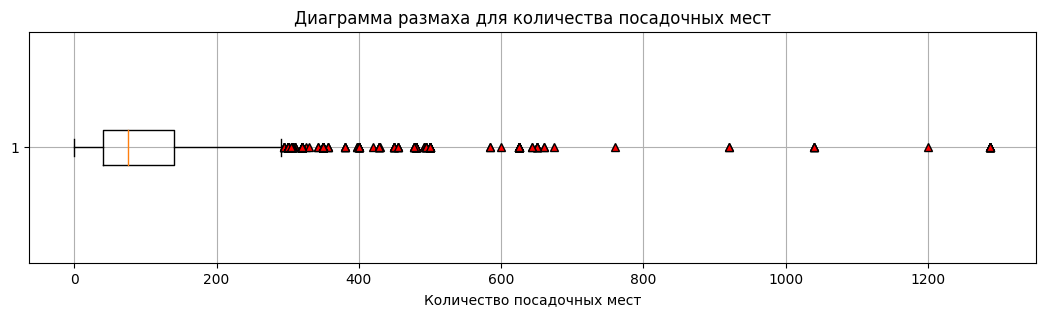

In [53]:
plt.figure(figsize=(13,3))
plt.boxplot(df_clean['seats'], vert=False, flierprops=dict(markerfacecolor='red',marker='^'))
plt.title('Диаграмма размаха для количества посадочных мест')
plt.xlabel('Количество посадочных мест')
plt.grid(True)

Такие значения кажутся не просто выбросами, а аномалиями.

Хотя возможно это фудкорты. Я на них ни разу не был, но вроде там общее пространство посадочных мест для разных заведений. Можно это проверить отсортировав по адресу заведения с большим количеством посадочных мест. Хотя это не 100%-ное доказательство.

In [54]:
df_clean[df_clean['seats']>=600].sort_values(by='address')

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup,is_24_7
2901,4a603ed5bc6043b7890ef13369e063ec,ресторан тройка,"бар,паб","москва, измайловское шоссе, 71, корп. 2б",ВАО,"ежедневно, 11:00–23:00",3.7,0,660,NaN,NaN,<NA>,<NA>,False
2913,abb5ad187013434c8c70f49c69ed1bb1,хаус бар,"бар,паб","москва, измайловское шоссе, 71, корп. 2б",ВАО,"ежедневно, 07:00–23:00",3.7,0,660,средние,средний счёт:500–1000 ₽,750,<NA>,False
2722,4731af3e68bb449fb2b34493fadfaed1,маргарита,быстрое питание,"москва, измайловское шоссе, 71, корп. а",ВАО,"ежедневно, 10:00–22:00",4.3,1,1040,NaN,NaN,<NA>,<NA>,False
2770,4c196f841b0046b3ab3a60d3ed52bfc5,шоколадница,кофейня,"москва, измайловское шоссе, 71, корп. а",ВАО,"пн-ср 11:00–23:00; чт 11:00–00:00; пт,сб 11:00...",4.1,1,1040,NaN,NaN,<NA>,<NA>,False
2713,8d07e2d1810b4dca9d4cb247d0335df3,ваня и гоги,"бар,паб","москва, измайловское шоссе, 71, корп. а",ВАО,"ежедневно, 11:00–06:00",4.2,0,1040,высокие,средний счёт:1000–2500 ₽,1750,<NA>,False
2966,6b611f2fc2084078952aaef40780f11c,матрешка,кафе,"москва, измайловское шоссе, 71, корп. а",ВАО,NaN,4.0,0,1040,NaN,NaN,<NA>,<NA>,False
4180,77141ea2e18e4f06867b6fef81f2aae4,eataly,"бар,паб","москва, киевская улица, 2",ЗАО,"ежедневно, 12:00–23:00",4.6,0,920,NaN,NaN,<NA>,<NA>,False
4245,1444de238c0f4de8a1de18ed0cb418f7,стейк & бургер,кафе,"москва, киевская улица, 2",ЗАО,"ежедневно, 09:00–21:00",4.2,1,920,NaN,NaN,<NA>,<NA>,False
4231,30d6c2abb42748bb98c01b1ed366e253,рестобар argomento,столовая,"москва, кутузовский проспект, 41, стр. 1",ЗАО,"ежедневно, 12:00–23:00",4.2,0,1200,высокие,средний счёт:2500–5000 ₽,3750,<NA>,False
1826,7f9d38d16f594858a2216c6ca44aa76f,волконский,булочная,"москва, ленинградский проспект, 29, корп. 1",САО,"ежедневно, 08:00–22:00",4.4,1,625,NaN,NaN,<NA>,<NA>,False


Понятней не стало. У некоторых заведений с одинаковым количеством посадочных мест одинаковый адрес, но не у всех. Хотя адрес очень близкий, но не настолько, чтобы это могло быть, например, фудкортом на улице для соседних зданий, в которых присутствуют данные заведения. Посмотрел по карте - да, здания находятся довольно далеко друг от друга.

Еще есть вариант, что это какие-нибудь огромные банкетные залы. Но почему тогда количество посадочных мест в точности совпадает, я не понимаю. Да и я слабо могу себе представить фудкорт на 1200+ мест, хотя, это Москва, все возможно.

- Из описания задания не совсем понятно, что имеется ввиду под `Приведите для каждой категории заведений наиболее типичное для него количество посадочных мест.` Имеется ввиду медиана или мода? По смыслу больше всего подходит мода, но я пожалуй сделаю и то, и другое.

Сначала сделаем датафрейм с группировкой и медианой по необходимым столбцам

In [55]:
# Группируем по категории, считаем медиану для посадочных мест и сортируем по убыванию
df_clean.groupby('category')['seats'].median().sort_values(ascending=False)

category
ресторан           86.0
бар,паб            82.0
кофейня            80.0
столовая           75.5
быстрое питание    65.0
кафе               60.0
пиццерия           55.0
булочная           50.0
Name: seats, dtype: Float64

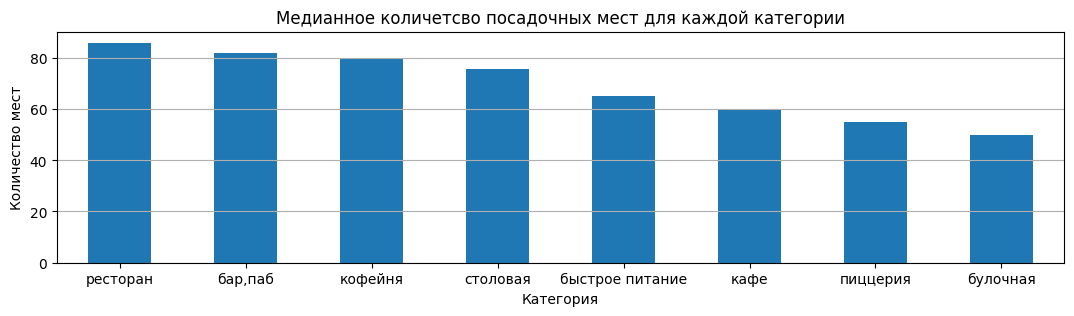

In [56]:
df_median = df_clean.groupby('category')['seats'].median().sort_values(ascending=False)
# Визуализируем полученные данные
df_median.plot(kind='bar',
               title='Медианное количетсво посадочных мест для каждой категории',
               legend=False,
               ylabel='Количество мест',
               xlabel='Категория',
               rot=0,
               figsize=(13,3),
               )
plt.grid(axis='y')

Рестораны, бары и кофейни в лидерах. Видимо потому, что люди туда ходят не только поесть, но и приятно время провести.

Столовые не сильно отстают от первой тройки. А вот фастфуд, кафе, пиццерии и булочные по медиане имеют значительно меньшее количество мест. Вероятно это происходит потому, что в столовых люди обычно непосредственно едят, а в фастфуде и ниже по списку люди еду могут взять с собой или вообще заказать. Еще может быть, что таким заведениям просто не выгодно иметь много посадочных мест.

- Мода посадочных мест с группировкой по категориям

In [57]:
# Группируем по категории, считаем моду для посадочных мест и сортируем по убыванию
df_clean.groupby('category')['seats'].agg(lambda x: pd.Series.mode(x)[0]).sort_values(ascending=False)

category
кофейня            100
ресторан           100
бар,паб             60
кафе                40
пиццерия            40
столовая            40
булочная             0
быстрое питание      0
Name: seats, dtype: UInt16

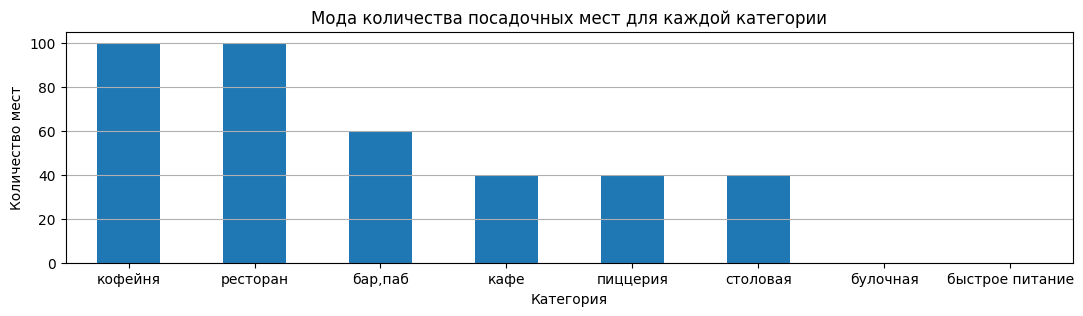

In [58]:
df_mode = df_clean.groupby('category')['seats'].agg(lambda x: pd.Series.mode(x)[0] if not pd.Series.mode(x).empty else None).sort_values(ascending=False)
# Визуализируем
df_mode.plot(kind='bar',
             title='Мода количества посадочных мест для каждой категории',
             legend=False,
             ylabel='Количество мест',
             xlabel='Категория',
             rot=0,
             figsize=(13,3),
             )
plt.grid(axis='y')

Интересные результаты. В плане расстановки мест почти ничего не поменялось, разве что различия стали радикальнее. Только у фастфуда внезапно мода оказалась равна нулю. По всей видимости в данных есть еще ларьки, которые продают еду только, что называется, "to go".

### 3.5 Средние рейтинги по категориям

In [59]:
df.groupby('category')['rating'].mean().sort_values(ascending=False)

category
бар,паб            4.387696
пиццерия           4.301264
ресторан           4.290401
кофейня            4.277282
булочная           4.268359
столовая           4.211429
кафе               4.124285
быстрое питание    4.050249
Name: rating, dtype: float32

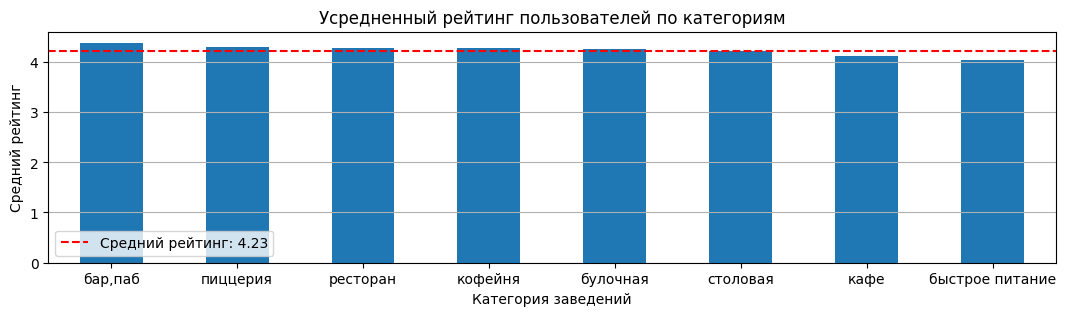

In [60]:
df.groupby('category')['rating'].mean().sort_values(ascending=False).plot(kind='bar',
                                            title='Усредненный рейтинг пользователей по категориям',
                                            legend=False,
                                            ylabel='Средний рейтинг',
                                            xlabel='Категория заведений',
                                            rot=0,
                                            figsize=(13,3))
# Включаем легенду только для линии со средним значение по всему столбцу rating
plt.legend(handles=[plt.axhline(df['rating'].mean(), color='red', linestyle='--')],
           labels=[f"Средний рейтинг: {df['rating'].mean():.2f}"])
plt.grid(axis='y')

Из визуализации видно, что средний рейтинг для каждой категории близок к среднему рейтингу по всем данным. Явно ниже среднего по всему датафрейму падают только быстрое питание и кафе. В среднем барами люди довольны больше, чем другими категориями)

### 3.6 Корреляции рейтинга заведений
Создадим матрицу корреляций с помощью библиотеки phik

In [61]:
# Создаем матрицу из необходимых для задания столбцов
corr_matrix = df[['category', 'district', 'chain', 'seats', 'price', 'is_24_7', 'rating']].phik_matrix()
# Выводим корреляции со столбцом rating, при этом отфильтровывая его же.
# Очевидно, что корреляция столбца с самим собой будет равна 1
corr_matrix.loc[corr_matrix.index != 'rating'][['rating']].sort_values(by='rating', ascending=False)

interval columns not set, guessing: ['chain', 'seats', 'rating']


,rating
price,0.262056
category,0.198739
district,0.189453
is_24_7,0.161010
chain,0.118857
seats,0.000000


Text(0.5, 14.722222222222216, 'Корреляция с рейтингом')

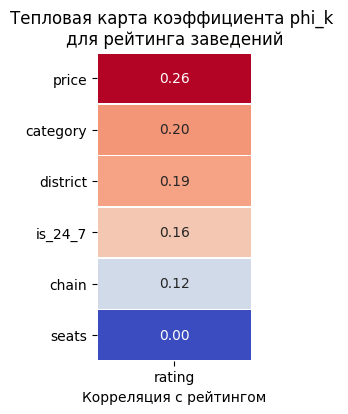

In [62]:
plt.figure(figsize=(2, 4))
# Сделаем тепловую карту для визуализации корреляций
data_heatmap = corr_matrix.loc[corr_matrix.index != 'rating'][['rating']].sort_values(by='rating', ascending=False)
sns.heatmap(data_heatmap,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            linewidths=0.5,
            cbar=False
           )
plt.title('Тепловая карта коэффициента phi_k \nдля рейтинга заведений')
plt.xlabel('Корреляция с рейтингом')

Все корреляции слабые. Со столбцом `seats` она вообще равна нулю. Проверим самую сильную из этих корреляций.

In [63]:
# Проверим средний рейтинг в срезе ценового сегмента
df.groupby('price')['rating'].mean().sort_values(ascending=False)

price
высокие          4.436611
выше среднего    4.386348
средние          4.297874
низкие           4.173077
Name: rating, dtype: float32

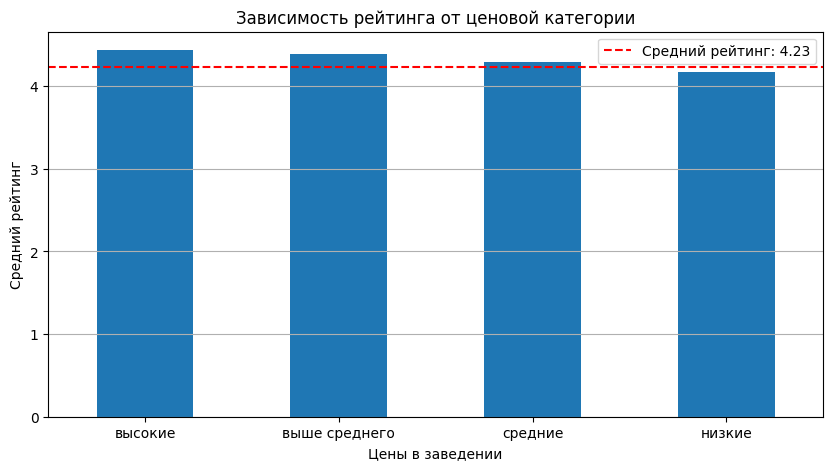

In [64]:
# Строим столбчатую диаграмму с линией для среднего рейтинга по всему датафрейму для наглядности
df.groupby('price')['rating'].mean().sort_values(ascending=False).plot(
                                         kind='bar',
                                         title='Зависимость рейтинга от ценовой категории',
                                         legend=False,
                                         xlabel='Цены в заведении',
                                         ylabel='Средний рейтинг',
                                         rot=0,
                                         figsize=(10,5))
plt.legend(handles=[plt.axhline(df['rating'].mean(), color='red', linestyle='--')],
           labels=[f"Средний рейтинг: {df['rating'].mean():.2f}"])
plt.grid(axis='y')

Визуализация показывает, что в данном датасете средний рейтинг имеет явную, хоть и слабую, зависимость от ценового сегмента заведения. В среднем, чем выше цены, тем лучше оценки люди ставят в приложении. Видимо это связано с уровнем сервиса.

### 3.7 Топ-15 популярный сетей общепита в Москве

Chain принимает значения 1 - для сетевых и 0 - для несетевых, т.е. если мы просуммируем этот столбец, то найдем количество сетевых заведений.

Сгруппируем данные по названию и сделаем агрегацию для `chain` - `sum` (считаем количество сетевых заведений), а для `rating` - `mean` (считаем средний рейтинг)

In [65]:
# Создаем датафрейм с нужными данными
df.groupby('name').agg({'chain': 'sum',
                       'rating': 'mean'}).sort_values(by='chain',ascending=False).head(15).reset_index()

,name,chain,rating
0,шоколадница,120,4.177500
1,домино'с пицца,76,4.171429
2,додо пицца,74,4.286487
3,one price coffee,71,4.069445
4,яндекс лавка,69,3.872464
5,cofix,65,4.075385
6,prime,50,4.116000
7,хинкальная,44,4.322727
8,кофепорт,42,4.147619
9,кулинарная лавка братьев караваевых,39,4.394872


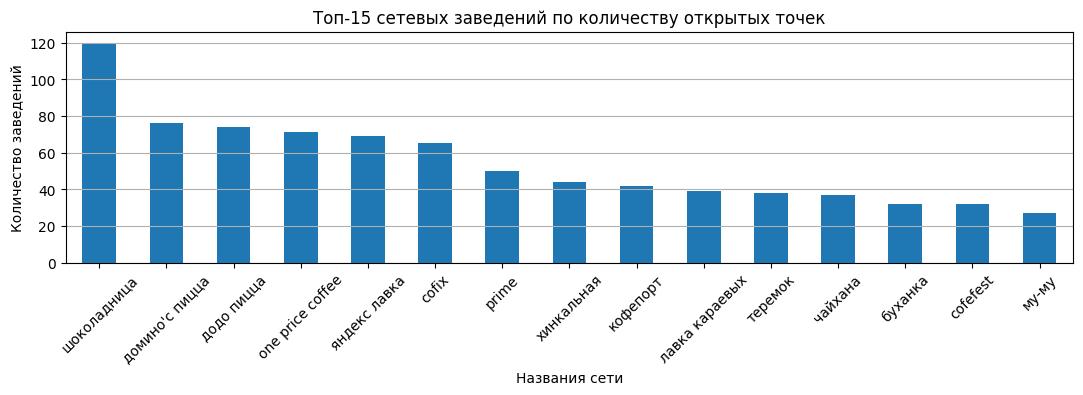

In [66]:
top_15 = df.groupby('name').agg({'chain': 'sum', 'rating': 'mean'}).sort_values(by='chain',ascending=False).head(15).reset_index()
top_15['name'].replace({'кулинарная лавка братьев караваевых':'лавка караевых'}, inplace=True)
top_15.set_index('name', inplace=True)
top_15['chain'].plot(kind='bar',
                     title='Топ-15 сетевых заведений по количеству открытых точек',
                     legend=False,
                     ylabel='Количество заведений',
                     xlabel='Названия сети',
                     rot=45,
                     figsize=(13,3))
plt.grid(axis='y')

`Шоколадница` лидирует с большим отрывом. `домино'с пицца`, `додо пицца`, `one price coffee`, `яндекс лавка`, `cofix` держатся в диапазоне 60-80. У остальных сетей открыто меньше 60-ти точек. 

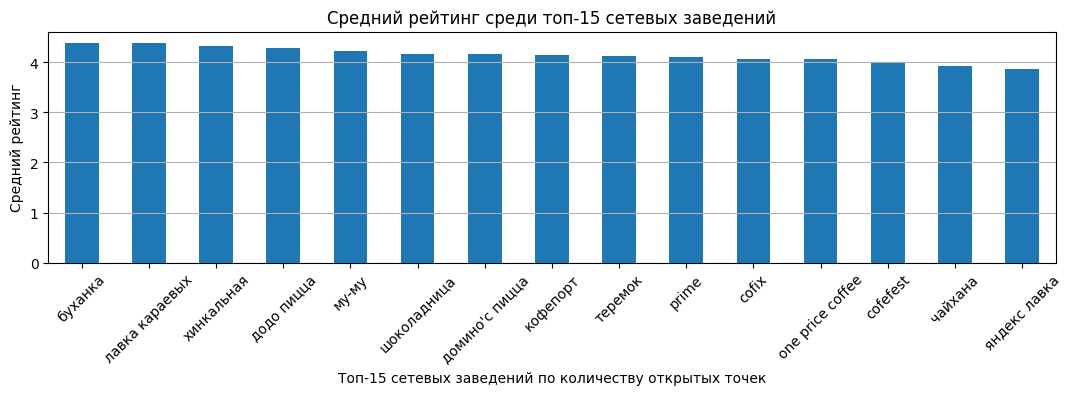

In [67]:
top_15['rating'].sort_values(ascending=False).plot(kind='bar',
                     title='Средний рейтинг среди топ-15 сетевых заведений',
                     legend=False,
                     ylabel='Средний рейтинг',
                     xlabel='Топ-15 сетевых заведений по количеству открытых точек',
                     rot=45,
                     figsize=(13,3))
plt.grid(axis='y')

Средний рейтинг у всех приблизительно похожий. Топ-3 - `буханка`, `лавка караевых`, `хинкальная`. Средний рейтинг упал ниже 4-х у `cofefest`, `чайхана`, `яндекс лавка`.

**Задание 2**

В датасете у сетевых заведений под одним названием может быть несколько категорий.

Задание можно выполнить двумя путями:
1. Сохранить все категории для каждой позиции в топ-15
2. Выбрать самое часто встречающееся значение и подставить его.

- Вариант с сохранением всех категорий:

In [68]:
# Создаем переменную для топ-15
top_15 = df.groupby('name').agg({'chain': 'sum', 'rating': 'mean'})\
           .sort_values(by='chain', ascending=False).head(15).reset_index()

# Создаем список из пары имя и категория без дубликатов
name_category = df[['name', 'category']].drop_duplicates()

# Объединяем датафреймы "левым" способом с сохранением всех значений из топ-15
top_15_merge=top_15.merge(name_category, how='left', on='name')

# Выводим столбцы "name" и "category" из нового объединенного датафрейма
top_15_merge[['name','category']]

,name,category
0,шоколадница,кофейня
1,шоколадница,кафе
2,домино'с пицца,пиццерия
3,додо пицца,пиццерия
4,one price coffee,кофейня
5,яндекс лавка,ресторан
6,cofix,кофейня
7,prime,ресторан
8,prime,кафе
9,хинкальная,быстрое питание


- Второй вариант - с модой по категории.

In [69]:
# Создадим список из значений столбца "name" датафрейма "top_15"
top_15_names = top_15['name'].tolist()

# Из списка сделаем маску для фильтрации
mask = df['name'].isin(top_15_names)

# Создадим датафрейм с фильтрацией по маске, группировке по "name" и с агрегацией по моде столбца "category"
mode_category = df[mask].groupby('name')['category'].agg(lambda x: x.mode()[0]).reset_index()

# Объединяем датасеты и смотрим, что получилось
top_15.merge(mode_category, on='name', how='left')

,name,chain,rating,category
0,шоколадница,120,4.177500,кофейня
1,домино'с пицца,76,4.171429,пиццерия
2,додо пицца,74,4.286487,пиццерия
3,one price coffee,71,4.069445,кофейня
4,яндекс лавка,69,3.872464,ресторан
5,cofix,65,4.075385,кофейня
6,prime,50,4.116000,ресторан
7,хинкальная,44,4.322727,кафе
8,кофепорт,42,4.147619,кофейня
9,кулинарная лавка братьев караваевых,39,4.394872,кафе


### 3.8 Вариации медианного чека в зависимости от административного округа

В задании не сказано, что конкретно считать. Я посчитаю среднее, медиану, минимум и максимум `middle_avg_bill` с группировкой по округам. Так можно понять размах и косвенно представить тип распределения.

In [70]:
# Группируем данные по округам и считаем интересующие нас статистики
df.groupby('district').agg({'middle_avg_bill':['mean', 'median','min','max']}).sort_values(by=('middle_avg_bill','mean'),ascending=False)

middle_avg_bill                    
                    mean  median  min    max
district                                    
ЦАО          1192.182247  1000.0   67   7250
ЗАО           1053.22549  1000.0   50   5250
САО           927.959627   650.0  130  11000
ЮАО           834.398089   500.0  100  35000
СЗАО           822.22293   700.0  120   2900
ВАО           820.626923   575.0   50  10000
ЮЗАО          792.561702   600.0  100   2750
СВАО          716.611296   500.0   50   4500
ЮВАО          654.097938   450.0   30   3750

- Центральный округ ожидаемо выше всех по среднему медианному чеку
- Медиана и среднее сильно отличаются везде, кроме `ЗАО`. Что говорит нам о том, что нормальное распределение по медианному чеку, вероятнее всего, встречается только в Западном административном округе.
- Медиана везде меньше среднего, что говорит о больших правых востах распределений. Кроме `ЗАО`, опять же.

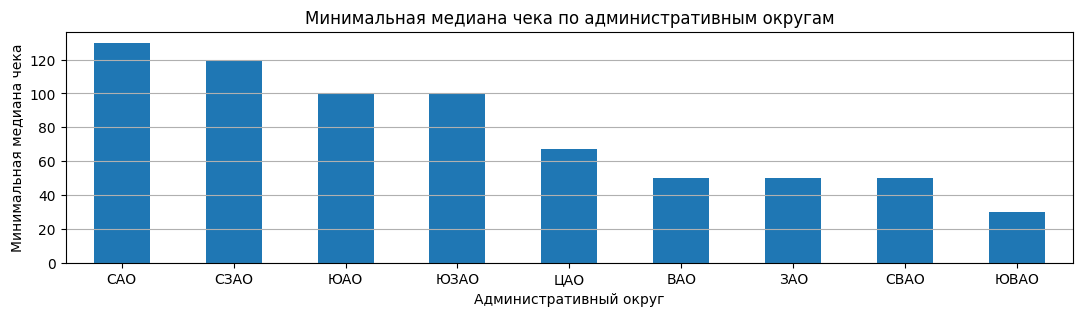

In [71]:
df_avg_bill = df.groupby('district')['middle_avg_bill'].min().sort_values(ascending=False)
df_avg_bill.plot(kind='bar',
                title='Минимальная медиана чека по административным округам',
                xlabel='Административный округ',
                ylabel='Минимальная медиана чека',
                rot=0,
                figsize=(13,3))
plt.grid(axis='y')

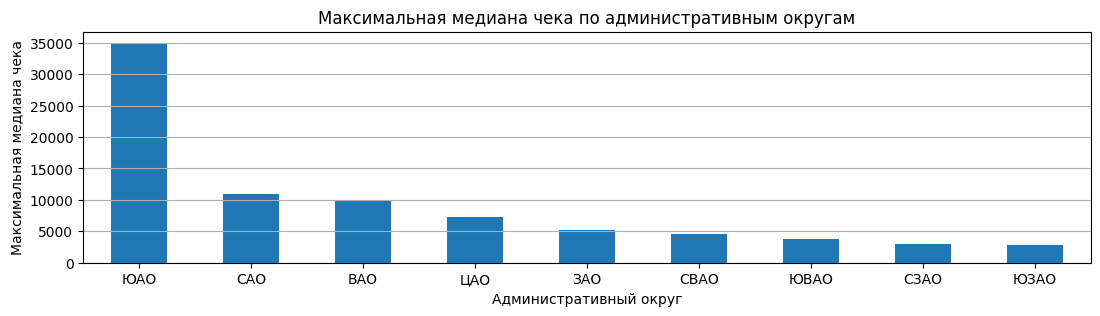

In [72]:
df_avg_bill = df.groupby('district')['middle_avg_bill'].max().sort_values(ascending=False)
df_avg_bill.plot(kind='bar',
                title='Максимальная медиана чека по административным округам',
                xlabel='Административный округ',
                ylabel='Максимальная медиана чека',
                rot=0,
                figsize=(13,3))
plt.grid(axis='y')

In [73]:
df[df['middle_avg_bill']==35000]

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup,is_24_7
7177,07b4e95afe8b4d299f823dc4f9de6df5,кафе,ресторан,"москва, каширское шоссе, 23, стр. 2",ЮАО,"ежедневно, круглосуточно",4.1,0,100,высокие,средний счёт:20000–50000 ₽,35000,<NA>,True


Видимо какой-то элитный ресторан со впечатляющим ценником и не впечатлающим названием)

- По минимуму и максимуму, на удивление, Центральный округ держится в середине. Минимальный медианный чек там ниже, чем в `САО`, `СЗАО`, `ЮАО` и `ЮЗАО`. Хотя для меня загадка, почему по `ЦАО` в датасете нет заведения(ий) со средним ценником выше хотя бы в 10 000.

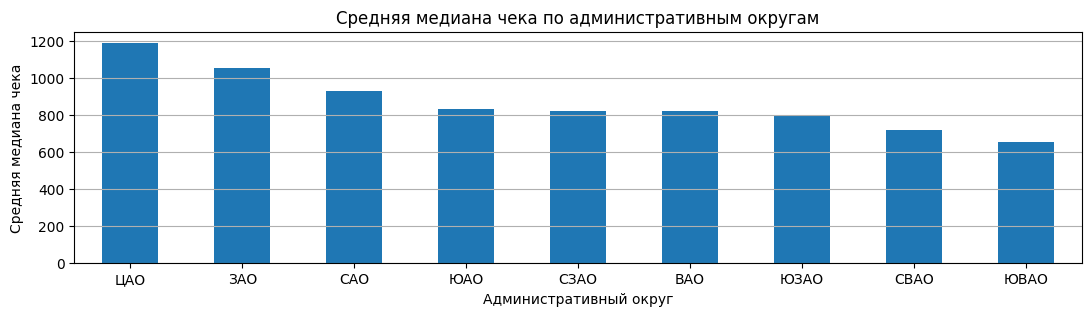

In [74]:
df_avg_bill = df.groupby('district')['middle_avg_bill'].mean().sort_values(ascending=False)
df_avg_bill.plot(kind='bar',
                title='Средняя медиана чека по административным округам',
                xlabel='Административный округ',
                ylabel='Средняя медиана чека',
                rot=0,
                figsize=(13,3))
plt.grid(axis='y')

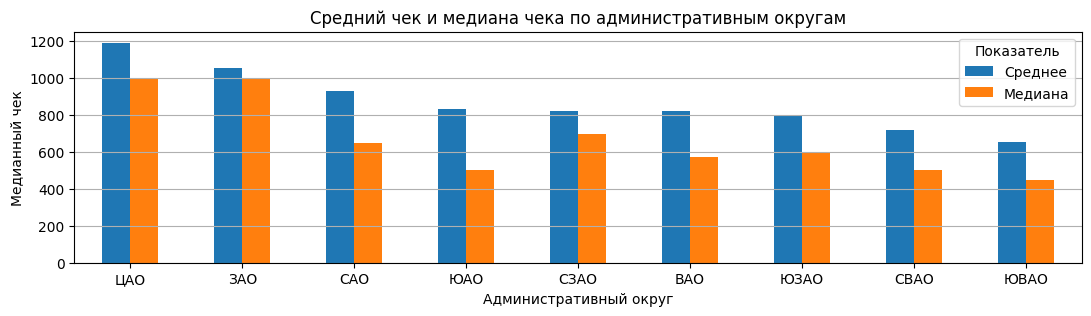

In [75]:
df_avg_bill = df.groupby('district').agg({'middle_avg_bill':['mean', 'median']}).sort_values(by=('middle_avg_bill','mean'),ascending=False)
df_avg_bill.columns = ['Среднее', 'Медиана']
df_avg_bill.plot(kind='bar',
                title='Средний чек и медиана чека по административным округам',
                xlabel='Административный округ',
                ylabel='Медианный чек',
                rot=0,
                figsize=(13,3))
plt.legend(title='Показатель')
plt.grid(axis='y')

- По среднему медианному чеку `ЦАО` впереди с неплохим отрывом и разницей с последним местом почти в два раза. По поводу удаленности от центра и ценника мне тяжело судить. По карте все эти администратиные округа выглядят равноудаленными. Тут видимо какая-то зависимость от экономики и географии округа. В общем в этом датасете такой информации нет, а сам я про Москву ничего не знаю, могу только предполагать.

Предположения:
1. `ЦАО` - исторический и деловой центр Москвы, где сосредоточено много штаб-квартир крупных бизнесов и проходят туристические маршруты. Высокие доходы и платежеспособность клиентов позволяют заведениям устанавливать более высокие цены.

`ЮВАО` считается менее престижным (видимо), с более низким уровнем доходов населения и большей долей спальных районов. Округа, такие как `ЗАО`, `САО`, `ЮЗАО` и другие, находятся в промежуточной зоне по уровню доходов.

2. Из-за высокой платежеспособности населения и потока туристов в `ЦАО` преобладают дорогие рестораны, кафе премиум-класса и туристические заведения с высокими стандартами обслуживания и предлагающие уникальный опыт.

`ЮВАО и другие периферийные округа`: Здесь больше фастфуда, столовых и бюджетных кафе, ориентированных на местных жителей.

3. Разница в стоимости аренды в центре и переферийных округах может сильно влиять на медианный ценник.

## 4. Итоговый вывод и рекомендации

### 4.1 Обзор проделанной работы

1. Загрузили данные из датасетов `rest_info` и `rest_price` и объединили их в один датафрейм `df`
2. Поменяли типы данных и провели предобработку данных. С пропусками было решено ничего не делать, потому что, из-за количества, мне непонятно как и чем их можно заполнить, без потери качества данных. Удалять их тоже не имеет смысла, опять же из-за количества. Как вариант можно было заменить пропуски на индикаторы с помощью метода `.fillna()`.
3. Провели исследовательский анализ данных по заданиям.

### 4.2 Ответы на исследовательские вопросы

1. `Кафе`, `Ресторан` и `Кофейня` с серьезным отрывом являются самыми большими категориями общепита с точки зрения количества заведений. `Столовая` и `Булочная`, в свою очередь, самые отстающие по этому показателю. `Бар`, `Пиццерия` и `Быстрое питание` в середине.

2. - В данных представлены такие административные округа: `САО`, `СВАО`, `СЗАО`, `ЗАО`, `ЦАО`, `ВАО`, `ЮВАО`, `ЮАО`, `ЮЗАО`.
   - В `ЦАО` открыто больше всего заведений общепита (2242) с отрывом от второго места `САО` (900) больше чем в два раза и разницей с последний местом `СЗАО` (409) больше чем в пять раз.
   - При этом в `ЦАО` смещенное, по сравнению со всем датасетом, распределение количества заведений по категориям. Количество ресторанов и баров сильно выше, а доля пиццерий и фастфудов ниже.

3. - Соотношение несетевых и сетевых заведений примерно 62/38, т.е. несетевых примерно в полтора раза больше.
   - `Булочные` чуть больше, чем в 60% случаев бывают сетевыми.
   - `Кофейни` и `пиццерии` чаще бывают сетевыми, чем несетевыми, но разница небольшая (~51% сетевых).
   - Остальные категории в подавляющем большинстве случаев несетевые.

4. - По всей видимости в данных есть выбросы и аномалии по количеству посадочных мест. Огромные значения в этом столбце могут означать фудкорты или большие банкетные залы. Но почему по разным адресам абсолютно идентичные знаения я не представлю. Возможно аномалии.
   - Если смотреть по медиане, то большие значения посадочных мест (`около 80ти`) у `ресторанов`, `баров`, `кофеен` и `столовых`. А у `фастфуда`, `кафе`, `пиццерий` и `булочных` - `65 и меньше`.
   - Агрегация с модой дает немного другую картину - у `кофеен` и `ресторанов` чаще всего встречается значение `100` посадочных мест, у `баров` - `60`, `кафе`, `пиццерии` и `столовые` - `40`. А вот `булочные` и `фастфуды` чаще всего бывают `без посадочных мест`.

5. Cредний рейтинг для каждой категории близок к среднему рейтингу по всем данным. Явно ниже среднего по всему датафрейму падают только `быстрое питание` и `кафе`. `Бары` - топ-1 по среднему рейтингу.

6. Самую большую (но слабую 0.26) корреляцию с рейтингом имеет ценовой сегмент заведения. Чем выше цены - тем выше средний рейтинг. Но диапазон небольшой - от `4.17` у `низкоценовых` заведений до `4.44` у заведений в ценовом сегменте `выше среднего`.

7. - Топ-15 сетей по количеству открытых точек: `шоколадница`, `домино'с пицца`, `додо пицца`, `one price coffee`, `яндекс лавка`, `cofix`, `prime`, `хинкальная`, `кофепорт`, `кулинарная лавка братьев караваевых`, `теремок`, `чайхана`, `cofefest`, `буханка`, `му-му`.
   - Cреди них встречаются такие категории: `кофейня`, `пиццерия`, `ресторан`, `кафе`, `булочная`, если смотреть по моде. У заведений одной сети может быть больше одной категории.
   - Средний рейтинг у всех приблизительно похожий. Топ-3 - `буханка`, `лавка караевых`, `хинкальная`. Средний рейтинг упал ниже 4-х у `cofefest`, `чайхана`, `яндекс лавка`.

8. - `ЦАО` ожидаемо выше всех по среднему медианному чеку.
   - Медиана и среднее сильно отличаются везде, кроме `ЗАО`. Что говорит нам о том, что нормальное распределение по медианному чеку, вероятнее всего, встречается только в `Западном административном округе`. Это значит, что по остальным в среднем значения не такие большие, но встречаются выбросы - видимо какие-то премиальные заведения с большими ценниками. Так же об этом говорит то, что медиана везде меньше среднего.
     
Разница в средних медианных ценниках может обосновываться несколькими причинами:
- `ЦАО` - исторический и деловой центр Москвы, где сосредоточено много штаб-квартир крупных бизнесов и проходят туристические маршруты. Высокие доходы и платежеспособность клиентов позволяют заведениям устанавливать более высокие цены.
- `ЮВАО` считается менее престижным (видимо), с более низким уровнем доходов населения и большей долей спальных районов. Округа, такие как `ЗАО`, `САО`, `ЮЗАО` и другие, находятся в промежуточной зоне по уровню доходов.
- Из-за высокой платежеспособности населения и потока туристов в `ЦАО` преобладают дорогие рестораны, кафе премиум-класса и туристические заведения с высокими стандартами обслуживания и предлагающие уникальный опыт.
- `ЮВАО и другие периферийные округа`: Здесь больше фастфуда, столовых и бюджетных кафе, ориентированных на местных жителей.
- Разница в стоимости аренды в центре и переферийных округах может сильно влиять на медианный ценник.

### 4.3 Рекомендации на основе анализа.

- При открытии заведения общепита в Москве нужно обратить внимание на округа с малой конкуренцией, т.е. где меньше всего открытых заведений, например: `СЗАО`.
- Так же нужно ориентироваться на средний ценовой сегмент представленный в том или ином регионе. Можно конечно попробовать открыть ресторан премиум-класса где-нибудь на периферии и понадеяться, что к вам будут съезжаться люди со всей Москвы, но я бы не стал так рисковать.
- Так же, помимо ценовой политики, нужно учитывать распределение заведений по категориям в том или ином административном округе. В центре, например, очень много ресторанов, но при этом очень мало пиццерий, фастфуда, столовых и булочных.

Исходя из данных в этих датасетах мне тяжело что-то еще предложить.